# **Методы оптимизации**
# **Лабораторная работа №2: «Метод ломаных»**
### **Работу выполнила:** Журбина Марина Андреевна

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import time

In [ ]:
def broken_line_method(func_str, a, b, eps, mode='min'):
    # Парсинг функции с помощью sympy
    x_sym = sp.Symbol('x')
    try:
        f_sym = sp.sympify(func_str)
    except Exception as e:
        raise ValueError(f"Ошибка парсинга функции: {e}")

    f = sp.lambdify(x_sym, f_sym, 'numpy')

    # Вычисление константы Липшица L
    f_prime_sym = sp.diff(f_sym, x_sym)
    f_prime = sp.lambdify(x_sym, f_prime_sym, 'numpy')
    x_test = np.linspace(a, b, 1000)
    L_estimated = np.max(np.abs(f_prime(x_test)))
    L = L_estimated * 1.1 # Коэффициент надежности
    if L == 0: L = 1.0

    print(f"\nРежим поиска: глобальный {mode.upper()}")
    print(f"Оцененная константа Липшица L: {L:.4f}")

    start_time = time.time()

    # Храним вычисленные точки
    X_eval = [a, b]
    Y_eval = [f(a), f(b)]

    # Функция расчета пересечения зависит от того, ищем мы min или max
    def calc_intersection(x1, x2, y1, y2):
        if mode == 'min':
            x_int = (x1 + x2) / 2 + (y1 - y2) / (2 * L)
            y_int = (y1 + y2) / 2 - L * (x2 - x1) / 2  # Строим миноранту
        else:
            x_int = (x1 + x2) / 2 - (y1 - y2) / (2 * L)
            y_int = (y1 + y2) / 2 + L * (x2 - x1) / 2  # Строим мажоранту
        return x_int, y_int

    intervals = []
    # Считаем самую первую вершину между концами отрезка a и b
    x_int, y_int = calc_intersection(a, b, Y_eval[0], Y_eval[1])
    intervals.append((y_int, x_int, a, b, Y_eval[0], Y_eval[1]))

    iterations = 0

    # Основной цикл алгоритма
    while True:
        iterations += 1

        # Если ищем минимум - сортируем по возрастанию y, если максимум - сортируем по убыванию y
        if mode == 'min':
            intervals.sort(key=lambda item: item[0])
        else:
            intervals.sort(key=lambda item: item[0], reverse=True)

        best_interval = intervals.pop(0)
        y_bound, x_new, x_l, x_r, y_l, y_r = best_interval

        # Вычисляем истинное значение функции
        y_new = f(x_new)
        X_eval.append(x_new)
        Y_eval.append(y_new)

        # Критерий останова
        if mode == 'min':
            f_best_current = min(Y_eval)
            if (f_best_current - y_bound) <= eps:
                break
        else:
            f_best_current = max(Y_eval)
            if (y_bound - f_best_current) <= eps:
                break

        # Добавляем два новых интервала
        x_int1, y_int1 = calc_intersection(x_l, x_new, y_l, y_new)
        intervals.append((y_int1, x_int1, x_l, x_new, y_l, y_new))

        x_int2, y_int2 = calc_intersection(x_new, x_r, y_new, y_r)
        intervals.append((y_int2, x_int2, x_new, x_r, y_new, y_r))

    calc_time = time.time() - start_time

    # Сортируем найденные точки
    sorted_indices = np.argsort(X_eval)
    X_eval = np.array(X_eval)[sorted_indices]
    Y_eval = np.array(Y_eval)[sorted_indices]

    if mode == 'min':
        best_idx = np.argmin(Y_eval)
        label_opt = 'Минимум'
        color_opt = 'green'
        bound_label = 'Миноранта (нижняя граница)'
    else:
        best_idx = np.argmax(Y_eval)
        label_opt = 'Максимум'
        color_opt = 'red'
        bound_label = 'Мажоранта (верхняя граница)'

    # Координаты ответа
    x_opt = X_eval[best_idx]
    y_opt = Y_eval[best_idx]

    # Визуализация
    plt.figure(figsize=(12, 6))
    x_dense = np.linspace(a, b, 1000)
    y_dense = f(x_dense)
    plt.plot(x_dense, y_dense, 'b-', label='$f(x)$ (Исходная функция)', linewidth=2)

    x_broken, y_broken = [], []
    for i in range(len(X_eval) - 1):
        x1, x2 = X_eval[i], X_eval[i+1]
        y1, y2 = Y_eval[i], Y_eval[i+1]
        xi, yi = calc_intersection(x1, x2, y1, y2)
        x_broken.extend([x1, xi, x2])
        y_broken.extend([y1, yi, y2])

    # Рисуем ломаную
    plt.plot(x_broken, y_broken, 'r--', label=bound_label, alpha=0.7)
    # Рисуем реальные точки функции
    plt.scatter(X_eval, Y_eval, color='black', s=20, label='Вычисленные точки $f(x)$', zorder=5)
    # Рисуем звезду на найденном экстремуме
    plt.scatter(x_opt, y_opt, color=color_opt, s=150, marker='*', label=f'{label_opt} ({x_opt:.4f}, {y_opt:.4f})', zorder=6)

    plt.title(f"Метод ломаных ({mode}): {func_str}\nИтераций: {iterations}, Время: {calc_time:.4f} с")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("-" * 60)
    print(f"Результаты для функции: f(x) = {func_str}")
    print(f"Приближенное значение аргумента (x*): {x_opt:.6f}")
    print(f"Значение функции в экстремуме f(x*): {y_opt:.6f}")
    print(f"Количество итераций: {iterations}")
    print(f"Затраченное время: {calc_time:.4f} секунд")
    print("-" * 60)


Тест № 1: Поиск минимума f = x + sin(3.14159 * x)

Режим поиска: глобальный MIN
Оцененная константа Липшица L: 4.5557


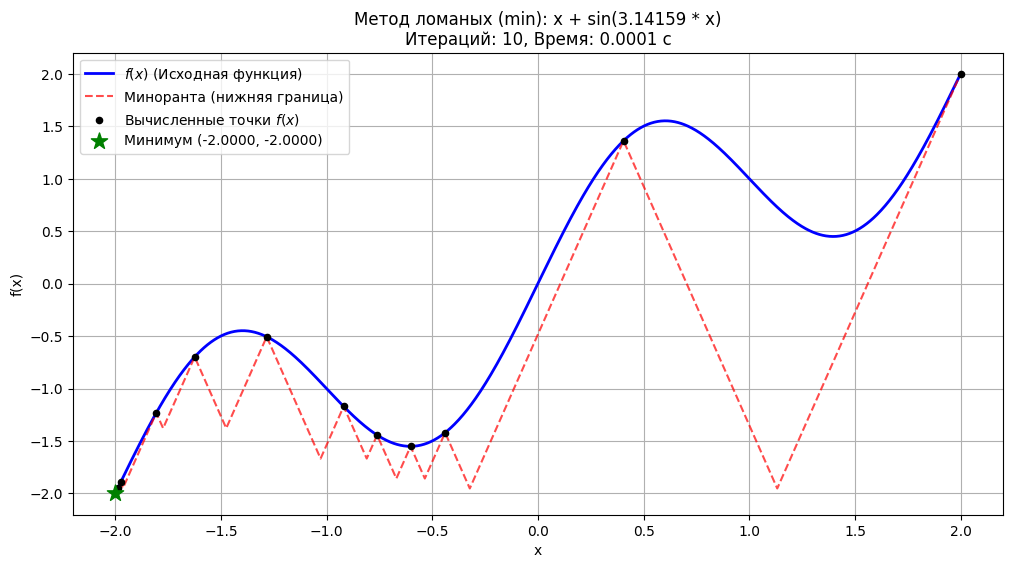

------------------------------------------------------------
Результаты для функции: f(x) = x + sin(3.14159 * x)
Приближенное значение аргумента (x*): -2.000000
Значение функции в экстремуме f(x*): -1.999995
Количество итераций: 10
Затраченное время: 0.0001 секунд
------------------------------------------------------------

Тест № 2: Поиск максимума f = x + sin(3.14159 * x)

Режим поиска: глобальный MAX
Оцененная константа Липшица L: 4.5557


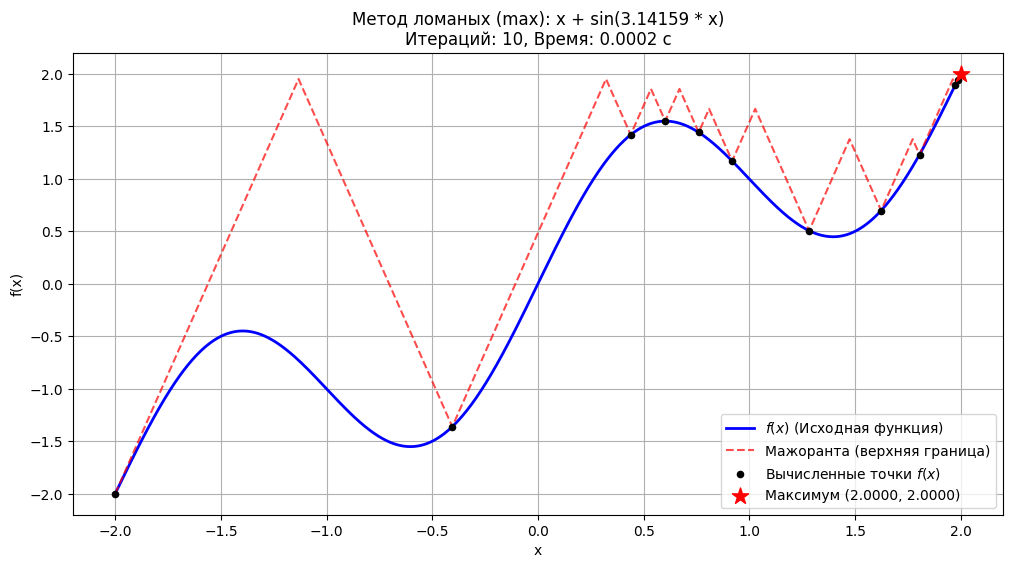

------------------------------------------------------------
Результаты для функции: f(x) = x + sin(3.14159 * x)
Приближенное значение аргумента (x*): 2.000000
Значение функции в экстремуме f(x*): 1.999995
Количество итераций: 10
Затраченное время: 0.0002 секунд
------------------------------------------------------------


In [ ]:
# Тестируем метод ломаных

print("Тест № 1: Поиск минимума f = x + sin(3.14159 * x)")
broken_line_method("x + sin(3.14159 * x)", -2.0, 2.0, 0.01, mode='min')

print("\nТест № 2: Поиск максимума f = x + sin(3.14159 * x)")
broken_line_method("x + sin(3.14159 * x)", -2.0, 2.0, 0.01, mode='max')

Тест № 3: Поиск минимума функции Растригина

Режим поиска: глобальный MIN
Оцененная константа Липшица L: 74.0644


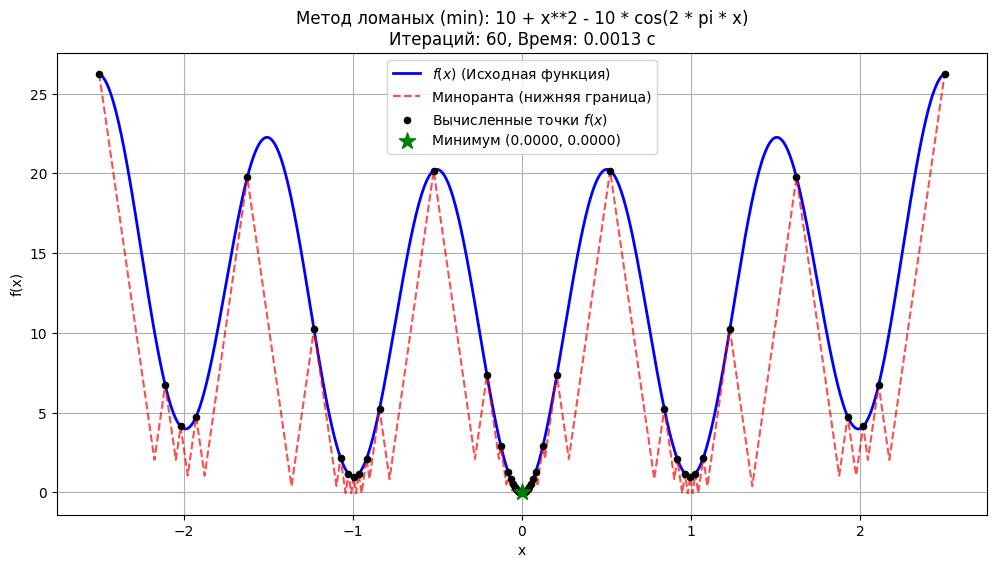

------------------------------------------------------------
Результаты для функции: f(x) = 10 + x**2 - 10 * cos(2 * pi * x)
Приближенное значение аргумента (x*): 0.000000
Значение функции в экстремуме f(x*): 0.000000
Количество итераций: 60
Затраченное время: 0.0013 секунд
------------------------------------------------------------

Тест № 4: Поиск минимума функции Экли 1D

Режим поиска: глобальный MIN
Оцененная константа Липшица L: 14.3546


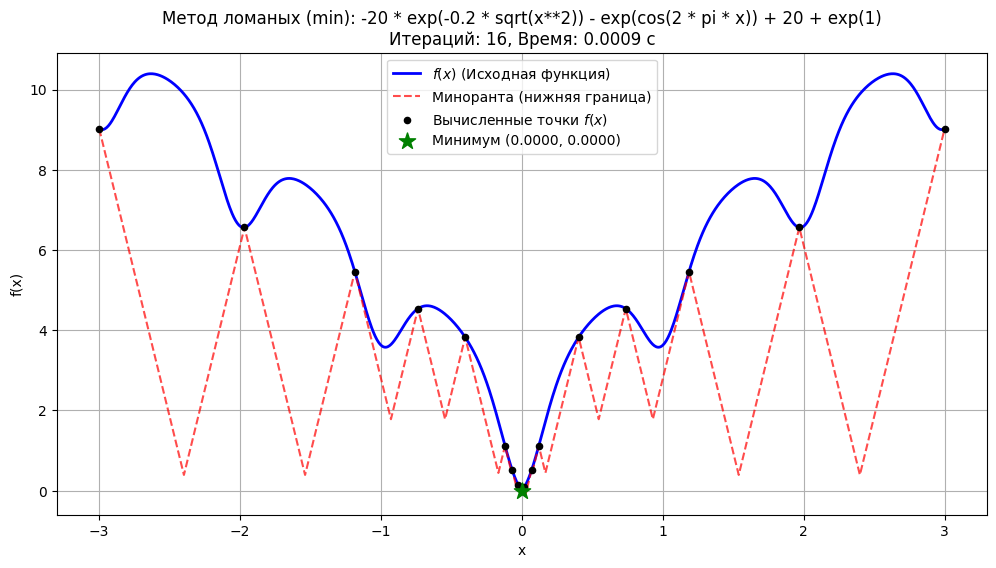

------------------------------------------------------------
Результаты для функции: f(x) = -20 * exp(-0.2 * sqrt(x**2)) - exp(cos(2 * pi * x)) + 20 + exp(1)
Приближенное значение аргумента (x*): 0.000000
Значение функции в экстремуме f(x*): 0.000000
Количество итераций: 16
Затраченное время: 0.0009 секунд
------------------------------------------------------------


In [ ]:
print("Тест № 3: Поиск минимума функции Растригина")
# Возьмем отрезок [-2.5, 2.5] - на нем будет 5 четких ям
# eps = 0.1, чтобы алгоритм не ушел в бесконечно долгое дробление
broken_line_method("10 + x**2 - 10 * cos(2 * pi * x)", -2.5, 2.5, 0.1, mode='min')

print("\nТест № 4: Поиск минимума функции Экли 1D")
ackley_str = "-20 * exp(-0.2 * sqrt(x**2)) - exp(cos(2 * pi * x)) + 20 + exp(1)"
broken_line_method(ackley_str, -3.0, 3.0, 0.1, mode='min')